Atmosphere Composition
  Species:   HI
  Mass frac: 1.00e+00

***** og: Mdot = 8.64e+09 g/s *****


0

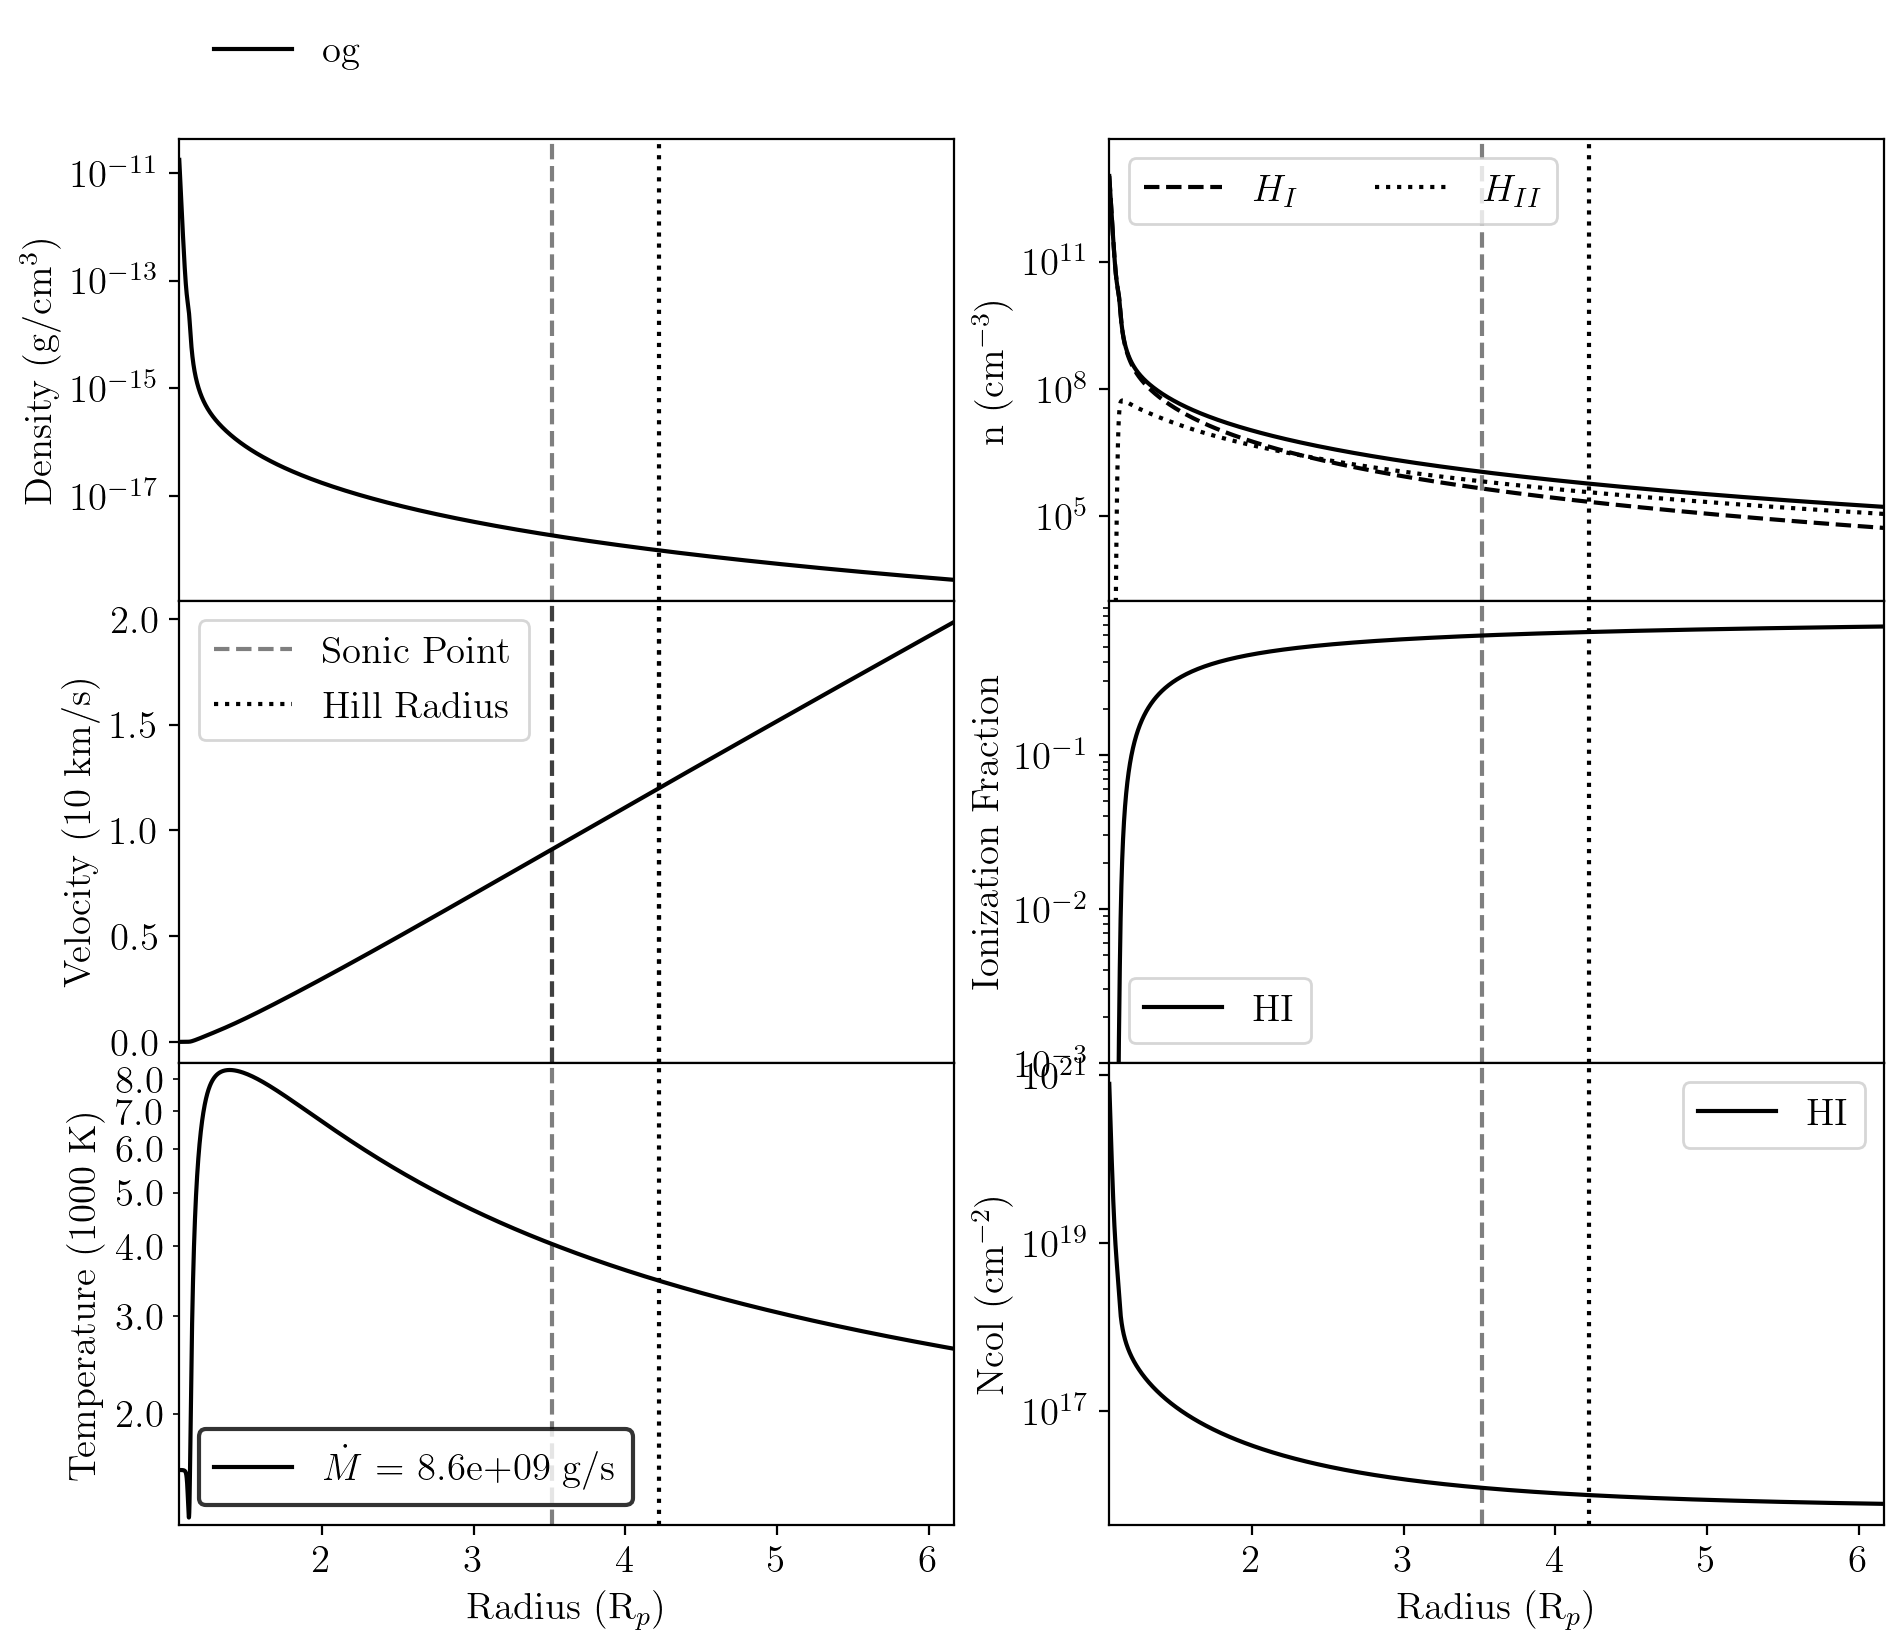

In [1]:
from wind_ae.wrapper.relax_wrapper import wind_simulation as wind_sim
from wind_ae.wrapper.wrapper_utils.windsoln import wind_solution as windsoln
from wind_ae.wrapper.wrapper_utils.metals import metal_class
from wind_ae.wrapper.wrapper_utils.plots import six_panel_plot
import wind_ae.wrapper.wrapper_utils.constants as const
import wind_ae.McAstro.atoms.atomic_species as McAtom
from wind_ae.wrapper.wrapper_utils.system import system


sim = wind_sim()
sim.load_planet('../saves/starting_solutions/start_HotJupiter_20eV_H.csv')
ax = six_panel_plot(sim.windsoln,label='og')
sim.run_wind()
# six_panel_plot(sim.windsoln, ax=ax,first_plotted=False,c='c',label='new')
# plt.show()

# sim = wind_sim()
# # sim.load_planet('../saves/starting_solutions/start_HotJupiter_XUV_H.csv')
# # sim.load_planet('../saves/Tutorial_examples/example_13.6-2000eV_solar_H-He-C-O.csv')
# sim.load_planet('../wind_ae/saves/test.csv')
# sim.add_metals(['CI'])
# print(sim.windsoln.current_metallicity())

In [3]:
sim.polish_bcs()

Polishing up boundary conditions...
   ...Trying: 1.354e-04, 3.410e-03. Current 1.354e-04, 3.414e-03. Goal 1.354e-04, 3.410e-03.                                      
Check energy_plot(). Stopping here.                                                                                                    

   ...Trying: 4.198e-04, 3.251e-03. Current 4.198e-04, 3.165e-03. Goal 4.198e-04, 3.251e-03.                                      
Check energy_plot(). Stopping here.                                                                                                    

  ...Attempting Final Ncol Convergence.                                                                                           
Successfully converged Rmax to 6.322100 (Ncol also converged).                                                                                                    

   ...Trying: 4.087e-04, 3.424e-03. Current 4.087e-04, 3.264e-03. Goal 4.087e-04, 3.424e-03.                                      
Ch

0

***** 222.70Mearth_15.68Rearth_450F_scaled-solar: Mdot = 7.74e+09 g/s *****


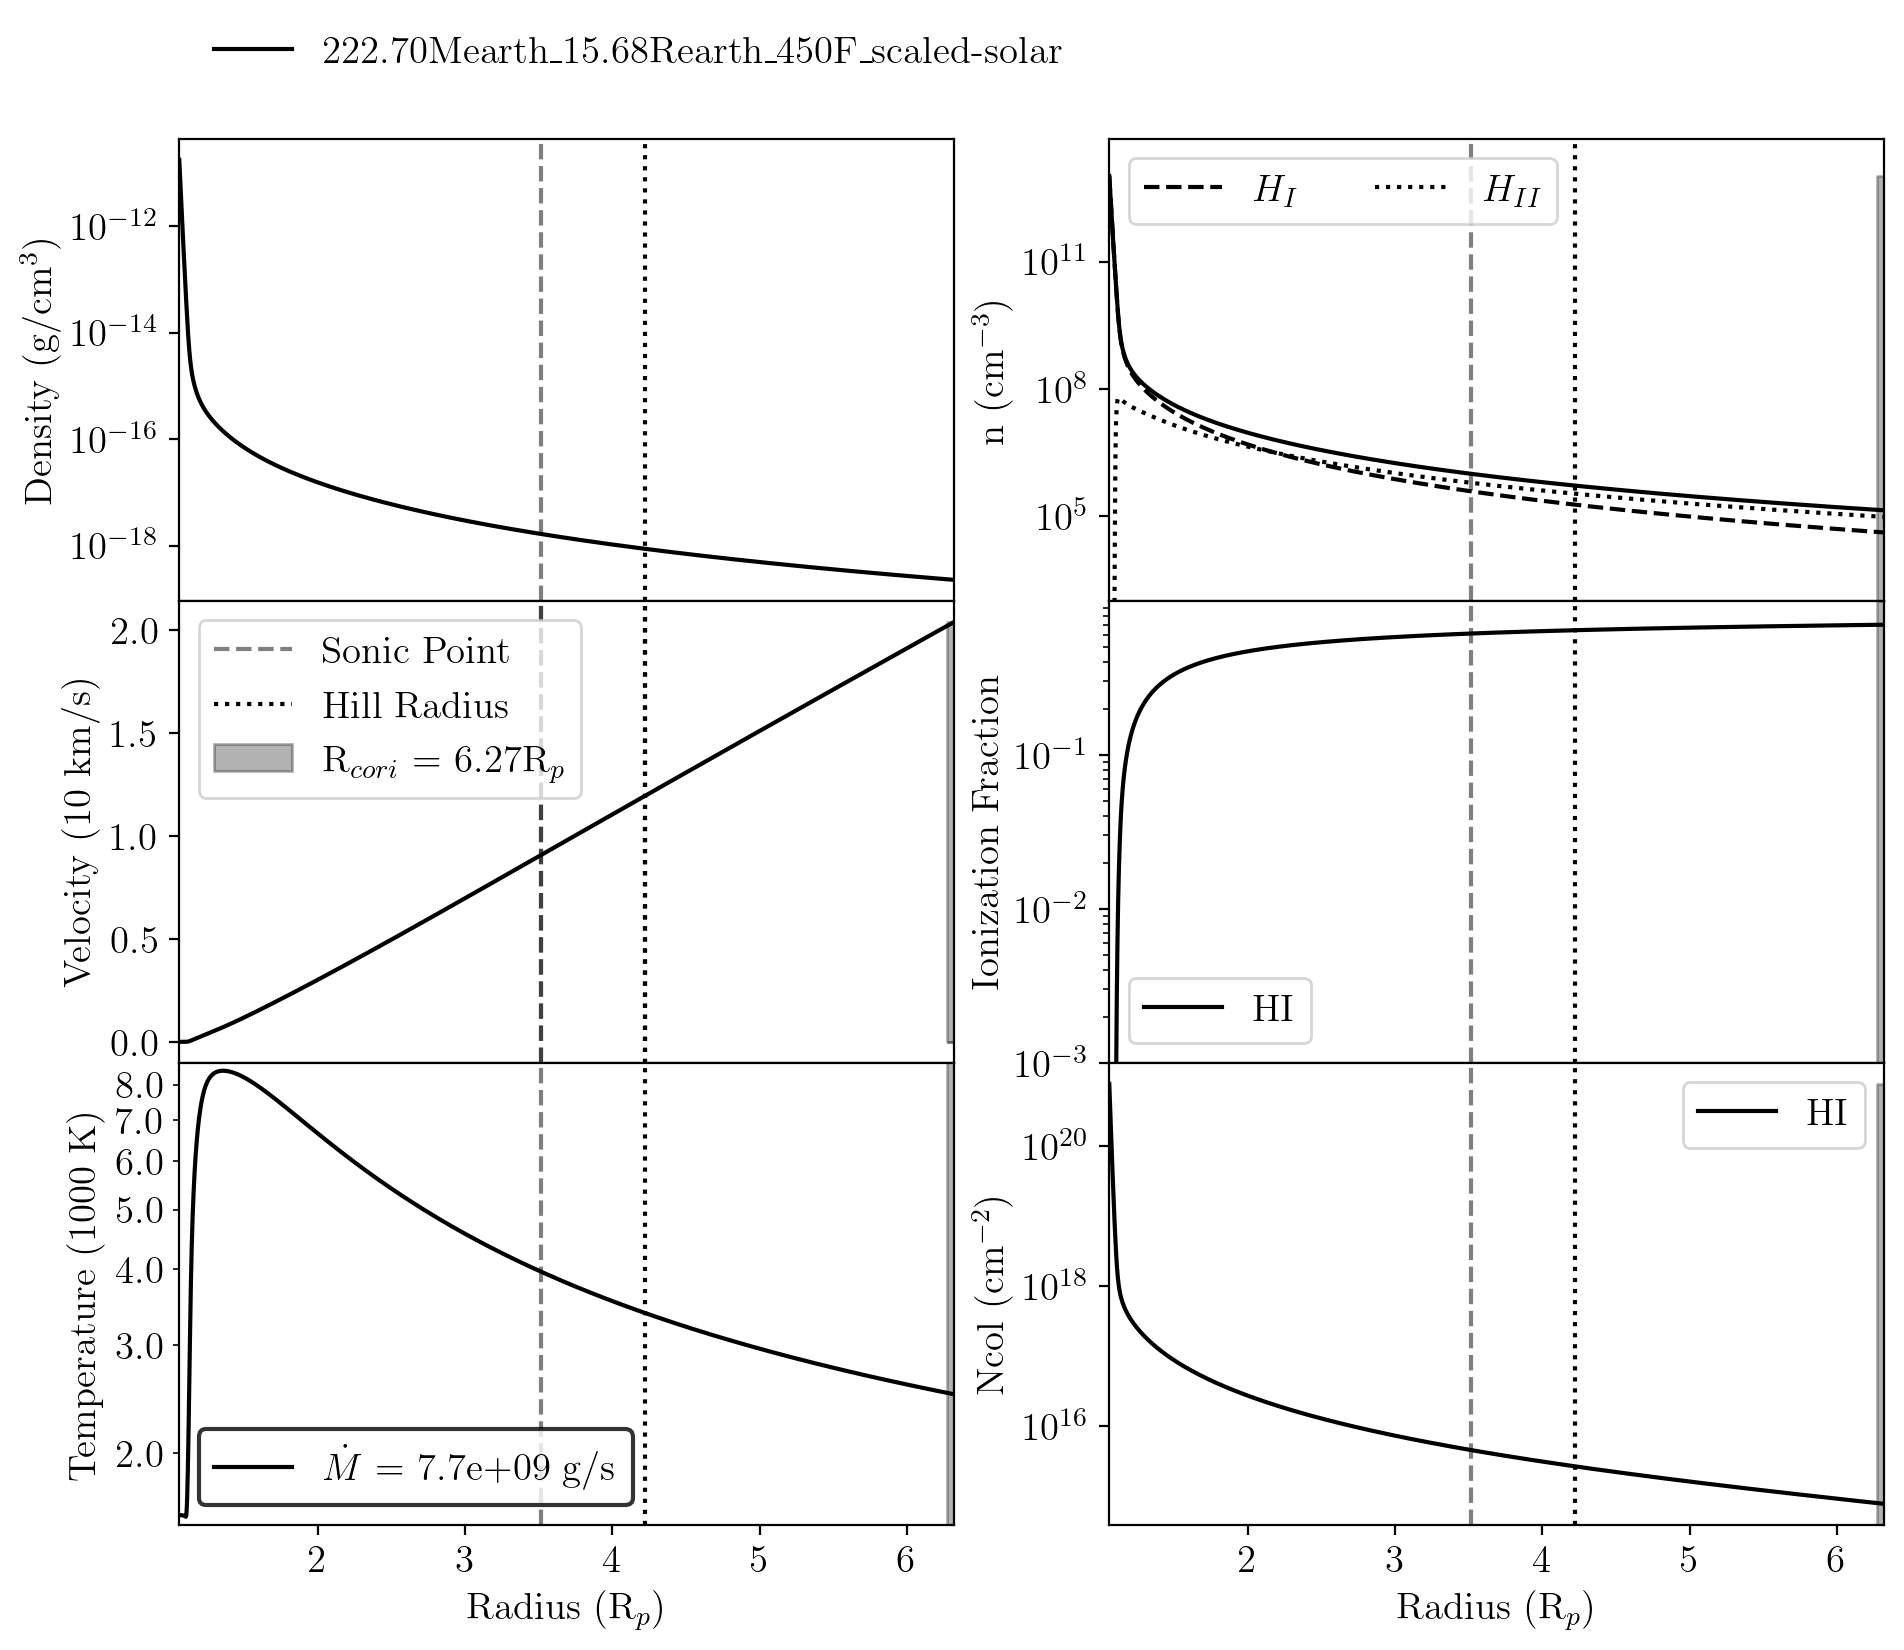

In [ ]:
sim.six_panel_plot()

In [10]:
sim.system.print_system()
print(sim.windsoln.Rmin, sim.windsoln.soln['rho'].iloc[0], sim.windsoln.soln['T'].iloc[0], sim.windsoln.soln['v'].iloc[0], sim.windsoln.soln['n_H'].iloc[0], sim.windsoln.soln['Ys_HI'].iloc[0])

Loaded Planet:
  System parameters (cgs)               # Normalized units
    Mp:        1.330000e+30 g           #     0.70 MJ
    Rp:        1.000000e+10 cm          #     1.40 RJ
    Mstar:     2.048068e+33 g           #     1.03 Msun
    semimajor: 7.031200e+11 cm          #     0.05 au
    Ftot:      4.500000e+02 erg/cm^2/s  # 9.64e+01 FuvEarth
    Lstar:     6.807420e+33 erg/s       # 1.78e+00 Lsun

1.059274285337 1.760847521936e-11 1583.04690456 0.9447664335287268 10523202784533.557 1.0


In [6]:
hd209 = system(sim.windsoln.Mp,sim.windsoln.Rp,const.Msun*1.03,0.047*const.au,450,sim.windsoln.Lstar)
sim.ramp_to(hd209,final_polish=True)

Ramping Ftot from 1.010e+03 to 4.500e+02 ergs/s/cm2.                                                     
  Final:  Ftot:4.500000e+02, delta:0.09906                                                                      
Ramping Mp from 1.330e+30 to 1.330e+30 g AND Rp from 1.000e+10 to 1.000e+10 cm.
  Mp already done.
  Rp already done.
Ramping Mstar from 1.988e+33 to 2.048e+33 AND semimajor from 7.480e+11 to 7.031e+11 AND Lstar from 6.807e+33 to 6.807e+33.
  Lstar already done.
  Final:  Mstar:2.048068e+33 & semimajor:7.031200e+11, M_delta:0.009804                                                    
Polishing up boundary conditions...
 Success! Average Ncol difference: 6.45e-02                                                                                       
Successfully converged Rmax to 6.169554 (Ncol also converged).                                                                                                    

   ...Trying: 1.354e-04, 2.599e-04. Current 8.029e-05, 4.373e-0

0

```
for sp in all_ionized_species:
  recombo_rate_sp = alpha(sp,T) * kB * T * n_e * n_ion_sp
  cooling_rate_sp = E_sp * recombo_rate_sp
```

In [49]:
print(self.Mp,self.Mstar,self.semimajor,self.Rp)

1.51881872e+30 1.988416e+33 748000000000.0 10723800000.0


In [48]:
sim.windsoln.R_sp

np.float64(3.7266270764689944)

In [ ]:
# crossover_masses = np.zeros((sim.windsoln.nspecies,len(sim.windsoln.soln['r'])))
crossover_masses = []
num_fracs = (sim.windsoln.HX/sim.windsoln.atomic_masses)/sum(sim.windsoln.HX/sim.windsoln.atomic_masses)
for i in range(sim.windsoln.nspecies):
    m_i = sim.windsoln.atomic_masses[i]/const.mH
    b_eff = 0.0
    for j in range(sim.windsoln.nspecies):
        if i==j: #skip diffusion with self
            continue
        m_j = sim.windsoln.atomic_masses[j]/const.mH

        b_ij = (m_i + m_j) / (2.0 * m_i * m_j) #
        b_eff += num_fracs[j] * b_ij
    
    jeans_param = const.G*sim.windsoln.Mp*m_i*const.mH/(const.kB*sim.windsoln.soln['T']*sim.windsoln.soln['r'])
    m_cross = m_i + (const.kB*sim.windsoln.soln['T'])/(b_eff*const.mH*sim.windsoln.soln['v']*jeans_param*sim.windsoln.soln['r'])

    crossover_masses.append(m_cross)
    # print(m_cross)
    # crossover_masses[i,:] = m_cross*const.mH
crossover_masses = np.stack(crossover_masses)
print(crossover_masses)
print(sim.windsoln.atomic_masses/const.mH)

[[ 3.1564667   3.06999531  2.98764673 ...  1.00000218  1.00000218
   1.00000217]
 [ 4.0069875   4.0055877   4.00425464 ...  3.97207861  3.97207861
   3.97207861]
 [11.92167344 11.92114462 11.92064102 ... 11.90848552 11.90848552
  11.90848552]
 [15.88303235 15.88262743 15.88224181 ... 15.87293409 15.87293409
  15.87293409]]
[ 1.          3.97207857 11.90848551 15.87293408]


In [4]:
# crossover_masses = np.zeros((sim.windsoln.nspecies,len(sim.windsoln.soln['r'])))
# crossover_masses = []
m_cross = np.zeros_like(sim.windsoln.soln['r'])
num_fracs = (sim.windsoln.HX/sim.windsoln.atomic_masses)/sum(sim.windsoln.HX/sim.windsoln.atomic_masses)
for i in range(sim.windsoln.nspecies):
    m_i = sim.windsoln.atomic_masses[i]/const.mH
    inv_b_eff = 0.0
    for j in range(sim.windsoln.nspecies):
        if i==j: #skip diffusion with self
            continue
        m_j = sim.windsoln.atomic_masses[j]/const.mH

        m_reduced = (m_i * m_j) / (m_i + m_j)
        b_ij = 1.5e18 * (sim.windsoln.soln['T'] ** 0.75)/ np.sqrt(m_reduced) #allegendly from Banks & Kockarts 
        inv_b_eff += num_fracs[j] / b_ij
    b_eff = 1.0 / inv_b_eff
    
    # print(b_eff)
    # print((const.kB*sim.windsoln.soln['T']*sim.windsoln.soln['v'])/(b_eff*g))
g = const.G*sim.windsoln.Mp/(sim.windsoln.soln['r']**2)
mdot = 4*np.pi*sim.windsoln.soln['r']**2*sim.windsoln.soln['rho']*sim.windsoln.soln['v']
Flux = mdot/(4*np.pi*sim.windsoln.soln['r']**2*sim.windsoln.soln['mu'])
print(const.kB*sim.windsoln.soln['T']*Flux / (b_eff*g*sim.windsoln.soln['n_tot']))
m_cross = sim.windsoln.soln['mu']/const.mH + const.kB*sim.windsoln.soln['T']*Flux / (b_eff*g*sim.windsoln.soln['n_tot'])
    # print((const.kB*sim.windsoln.soln['T']*sim.windsoln.soln['v'])/(b_eff*g*sim.windsoln.soln['n_tot']))
    # m_cross = sim.windsoln.soln['mu']/const.mH + (const.kB*sim.windsoln.soln['T']*sim.windsoln.soln['v'])/(b_eff*g)
    # jeans_param = const.G*sim.windsoln.Mp*m_i*const.mH/(const.kB*sim.windsoln.soln['T']*sim.windsoln.soln['r'])
    # m_cross = m_i + (const.kB*sim.windsoln.soln['T'])/(b_eff*const.mH*sim.windsoln.soln['v']*jeans_param*sim.windsoln.soln['r'])

    # if m_i
    # crossover_masses.append(m_cross)
    # print(m_cross)
    # crossover_masses[i,:] = m_cross*const.mH
# crossover_masses = np.stack(crossover_masses)
print(m_cross[:sim.windsoln.crit_index]/const.mH)
print(sim.windsoln.atomic_masses/const.mH)

0       7.457132e-37
1       7.770772e-37
2       8.098762e-37
3       8.439033e-37
4       8.794839e-37
            ...     
2496    8.064911e-29
2497    8.074596e-29
2498    8.084288e-29
2499    8.093988e-29
2500    8.103694e-29
Length: 2501, dtype: float64
0       1.374529e+24
1       1.374529e+24
2       1.374529e+24
3       1.374529e+24
4       1.374529e+24
            ...     
1285    3.763617e+23
1286    3.763593e+23
1287    3.763569e+23
1288    3.763545e+23
1289    3.763521e+23
Length: 1290, dtype: float64
[ 1.          3.97207857 11.90848551 15.87293408]


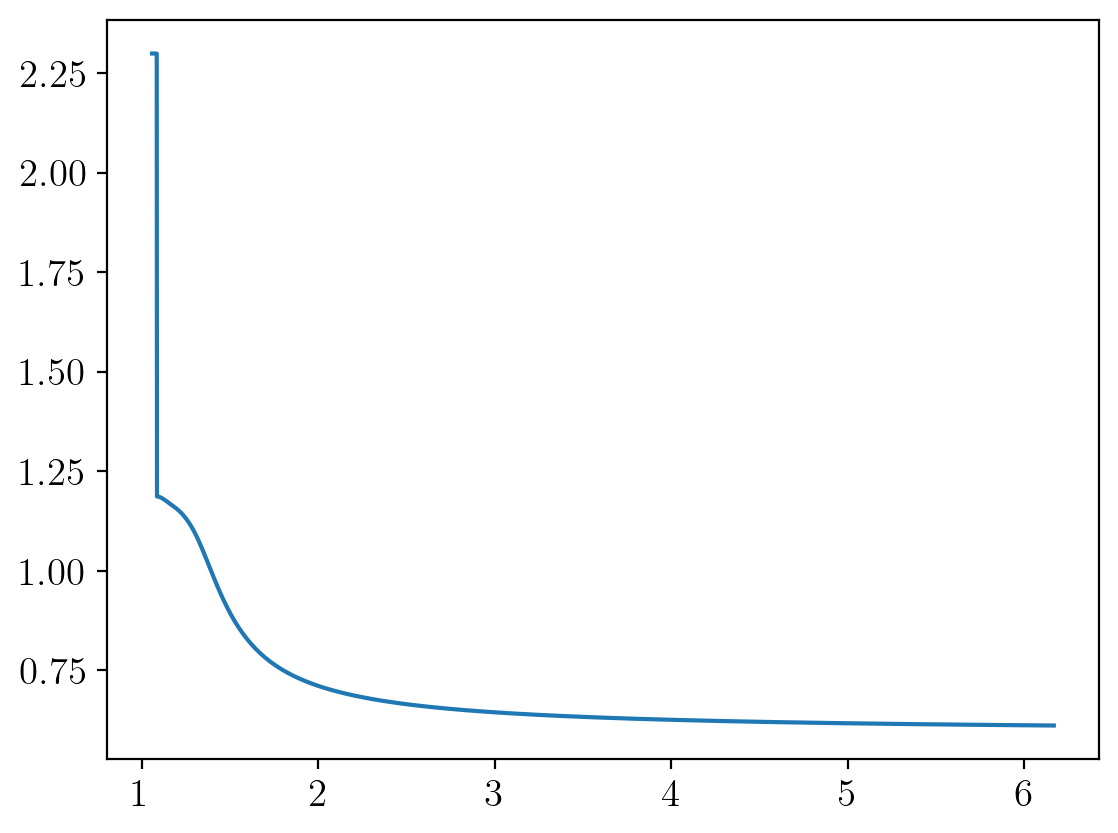

In [49]:
plt.plot(sim.windsoln.soln_norm['r'],m_cross)

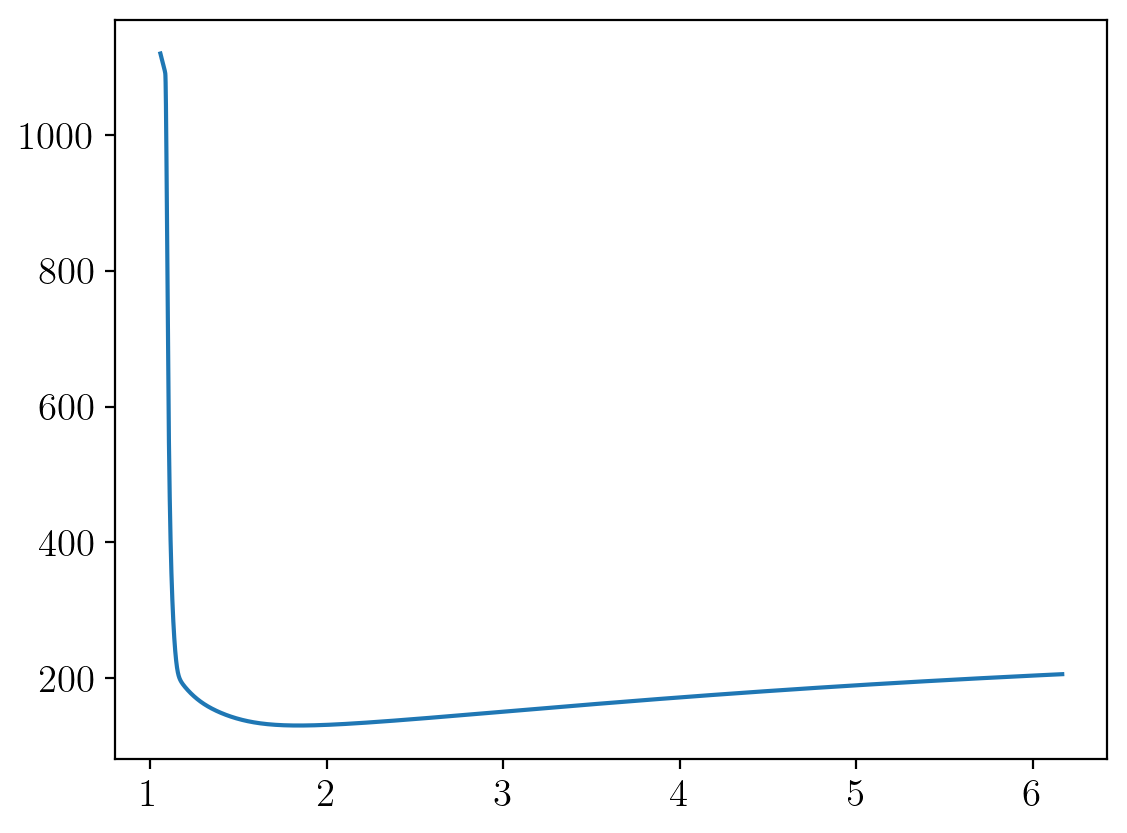

In [29]:
jeans_param = const.G*sim.windsoln.Mp*m_i*const.mH/(const.kB*sim.windsoln.soln['T']*sim.windsoln.soln['r'])

plt.plot(sim.windsoln.soln_norm['r'],jeans_param)

In [20]:
jeans_param = const.G*sim.windsoln.Mp*m_i/(const.kB*sim.windsoln.soln['T'])
m_cross = m_i + (const.kB*sim.windsoln.soln['T'])/(b_eff*sim.windsoln.soln['v']*jeans_param*sim.windsoln.soln['r'])
print(jeans_param)
print(b_eff)
print( (const.kB*sim.windsoln.soln['T'])/(b_eff*sim.windsoln.soln['v']*jeans_param*sim.windsoln.soln['r']))

0       1.270245e+13
1       1.270382e+13
2       1.270251e+13
3       1.270386e+13
4       1.270258e+13
            ...     
2496    1.358376e+13
2497    1.359095e+13
2498    1.359814e+13
2499    1.360534e+13
2500    1.361253e+13
Name: T, Length: 2501, dtype: float64
3.040446548266135e+23
0       2.493821e-60
1       2.393205e-60
2       2.297406e-60
3       2.204816e-60
4       2.116643e-60
            ...     
2496    4.341315e-67
2497    4.332685e-67
2498    4.324076e-67
2499    4.315488e-67
2500    4.306921e-67
Length: 2501, dtype: float64


In [4]:
# filepath = pkg_resources.files('wind_ae.McAstro.atoms').joinpath('Lodders.dat')
import pandas as pd

Z=10
lodders = pd.read_csv('../wind_ae/McAstro/atoms/Lodders.dat',comment='#',delimiter=' ')

# filepath = pkg_resources.files('wind_ae.McAstro.atoms').joinpath('atomic_masses.csv')
amu = pd.read_csv('../wind_ae/McAstro/atoms/atomic_masses.csv', comment='#')
N_per_N_H = 10**(lodders['A']-12)
mn = np.zeros_like(N_per_N_H)
for i,el in enumerate(lodders['name']):
    mass = (amu['mass'][amu['Symbol'] == el]).iloc[0]
    if (el != 'H') and (el != 'He'):
        mn[i] = mass*Z*N_per_N_H[i]
    else:
        mn[i] = mass*N_per_N_H[i]
solar_mass_frac = mn/np.sum(mn)
# print((solar_mass_frac))

species_list = sim.windsoln.species_list
el_list = [species.split()[0] for species in species_list]
Z_array = []
for element in el_list:
    Z_array = np.append(Z_array,solar_mass_frac[lodders['name']==element])

Z_array_new = Z_array/np.sum(Z_array)
print(Z_array_new)
temp_delta = (1-np.sum(Z_array))
Z_array[0] += temp_delta
print(Z_array)

[0.73036883 0.18603414 0.02134707 0.06224995]
[0.74434496 0.1763912  0.02024056 0.05902327]


In [2]:
sim.add_metals(['CI'],Z=2)

Metals added to guess, now ramping mass fractions.                                                                                        
Metals successfully added in at Z=1. Ramping to Z=2.                                                                                                    

Starting metallicity: 1 xSolar
  Attempting to ramp Z from 1.0 to 2.0                                                                                            Success! Ramped to goal metallicity, Z = 2 x Solar
  Integrating out and attempting to converge Ncol_sp...
  ...Attempting Final Ncol Convergence.                                                                                           
Successfully converged Rmax to 6.541080 (Ncol also converged).                                                                                                    



0

In [3]:
sim.run_wind(expedite=True)
np.round(sim.self_consistent_Ncol()[1][1],5)

This is an estimate of Ncol. Cannot converge precisely without outward integration.                                                                                                    



np.float64(0.00036)

In [2]:
# sim.windsoln.bolo_heat_cool = 0
sim.converge_mol_atomic_transition(polish=True)

   ...Trying: 1.056e-04, 4.911e-05. Current 1.592e-04, 4.911e-05. Goal 1.056e-04, 4.911e-05.                                      

0

In [6]:
val

In [2]:
sim.windsoln.calc_R_exo()

(np.float64(3.7614110624648514), 1294)

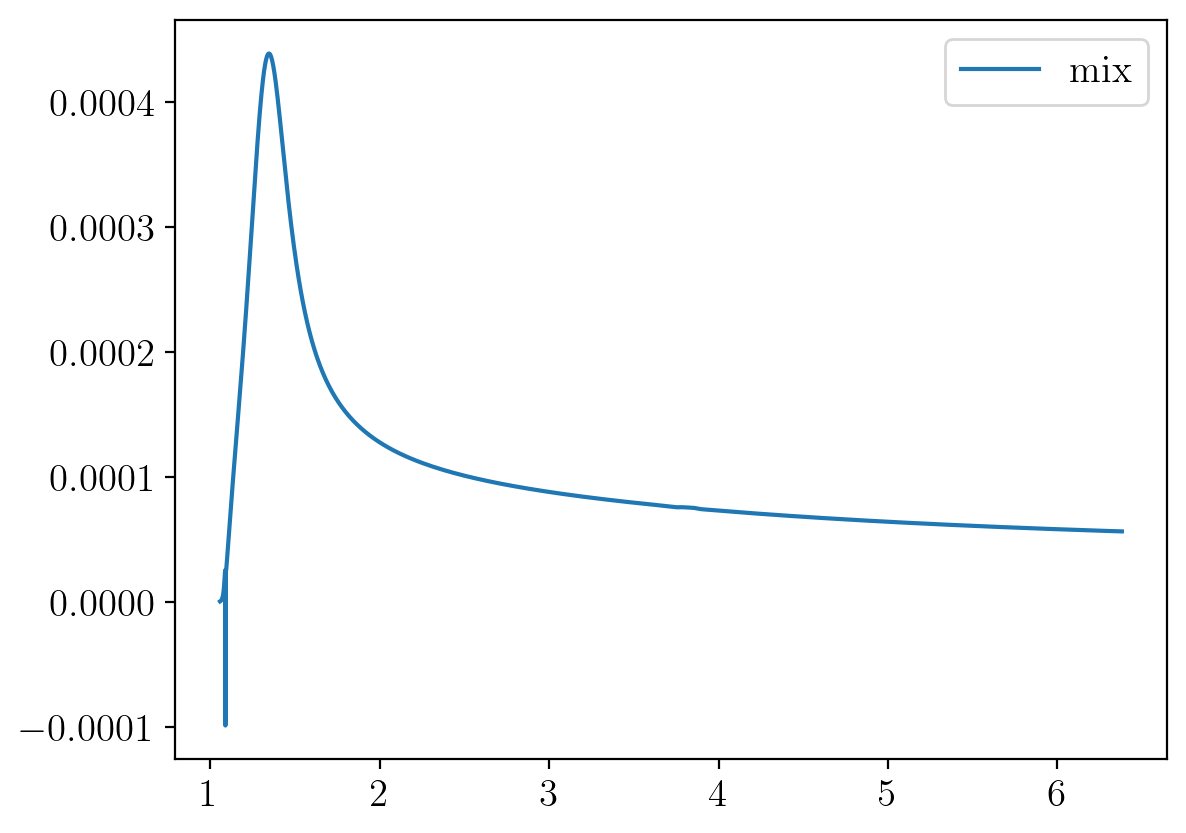

In [2]:
r = sim.windsoln.soln_norm['r']
# plt.plot(r,sim.windsoln.soln['Kn_Co_HI'],label='CO')
# plt.plot(r,sim.windsoln.soln['Kn_hb_HI'],label='hb')
plt.plot(r,sim.windsoln.soln['Kn_mx_HI'],label='mix')
plt.legend()
plt.show()

In [ ]:
sim